<a href="https://colab.research.google.com/github/ballushe4ka/homeworkMLSUNC/blob/main/task_numpy_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

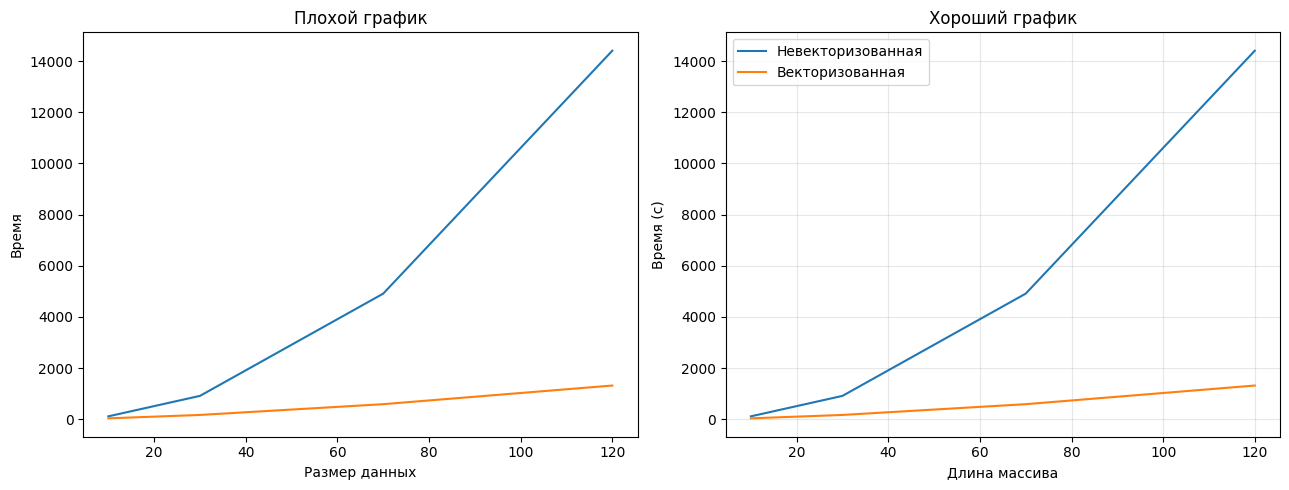

In [8]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

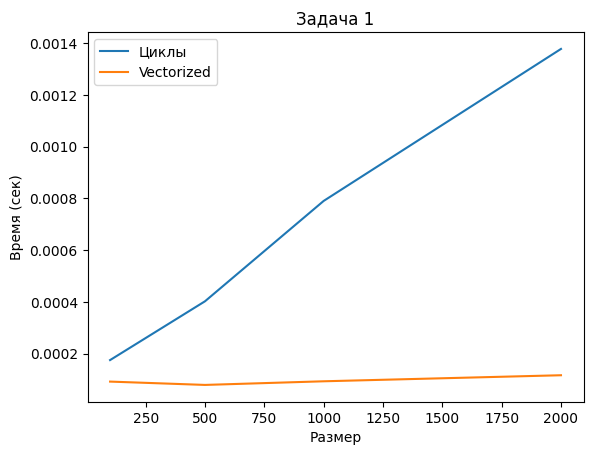

In [9]:
reload_solution_modules()

import time
import numpy as np
import matplotlib.pyplot as plt
sz = [100,500,1000,2000]
tl= []
tv = []
for i in sz:
    matrix = np.random.randint(0,5,size=(i,i))
    t0 = time.time()
    functions.prod_non_zero_diag(matrix)
    tl.append(time.time() - t0)
    t0 = time.time()
    functions_vectorized.prod_non_zero_diag(matrix)
    tv.append(time.time() - t0)
plt.plot(sz, tl, label='Циклы')
plt.plot(sz, tv, label='Vectorized')
plt.title('Задача 1')
plt.xlabel('Размер')
plt.ylabel('Время (сек)')
plt.legend()
plt.show()



* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


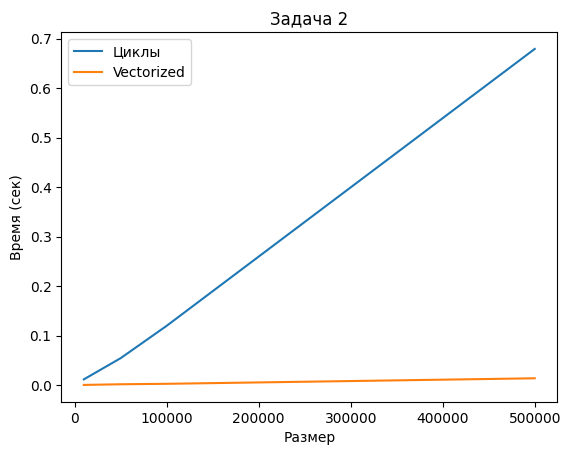

In [10]:
reload_solution_modules()
import time
import numpy as np
import matplotlib.pyplot as plt
sz = [10000, 50000, 100000, 500000]
tl = []
tv = []

for i in sz:
    x = np.random.randint(0, 1000, size=i)
    y = np.copy(x)
    np.random.shuffle(y)
    t0 = time.time()
    functions.are_multisets_equal(x, y)
    tl.append(time.time() - t0)
    t0 = time.time()
    functions_vectorized.are_multisets_equal(x, y)
    tv.append(time.time() - t0)

plt.plot(sz, tl, label='Циклы')
plt.plot(sz, tv, label='Vectorized')
plt.title('Задача 2')
plt.xlabel('Размер')
plt.ylabel('Время (сек)')
plt.legend()
plt.show()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

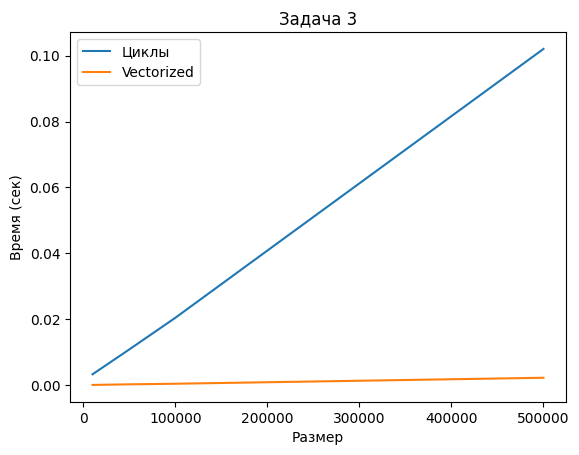

In [11]:
reload_solution_modules()
import time
import numpy as np
import matplotlib.pyplot as plt
sz = [10000, 50000, 100000, 500000]
tl = []
tv = []
for i in sz:
    x = np.random.randint(0, 10, size=i)
    t0 = time.time()
    functions.max_after_zero(x)
    tl.append(time.time() - t0)
    t0 = time.time()
    functions_vectorized.max_after_zero(x)
    tv.append(time.time() - t0)
plt.plot(sz, tl, label='Циклы')
plt.plot(sz, tv, label='Vectorized')
plt.title('Задача 3')
plt.xlabel('Размер')
plt.ylabel('Время (сек)')
plt.legend()
plt.show()



* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


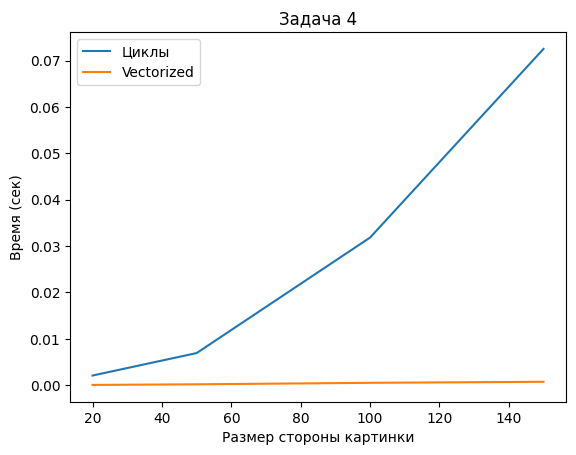

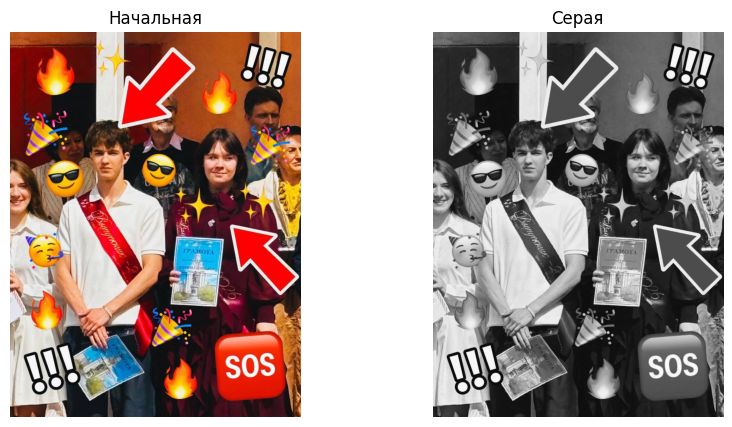

In [16]:
reload_solution_modules()
import time
import numpy as np
import matplotlib.pyplot as plt
sz = [20, 50, 100, 150]
tl = []
tv = []
coefs = np.array([0.299,0.587,0.114])
for i in sz:
    img = np.random.randint(0,256,size=(i,i,3))
    t0 = time.time()
    functions.convert_image(img,coefs)
    tl.append(time.time()-t0)
    t0 = time.time()
    functions_vectorized.convert_image(img,coefs)
    tv.append(time.time()-t0)
plt.plot(sz,tl,label='Циклы')
plt.plot(sz,tv,label='Vectorized')
plt.title('Задача 4')
plt.xlabel('Размер стороны картинки')
plt.ylabel('Время (сек)')
plt.legend()
plt.show()
from PIL import Image
img = np.asarray(Image.open('test.jpg').convert("RGB"))
res = functions_vectorized.convert_image(img, coefs)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img)
ax1.set_title("Начальная")
ax1.axis('off')
ax2.imshow(res, cmap='gray')
ax2.set_title("Серая")
ax2.axis('off')
plt.show()

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

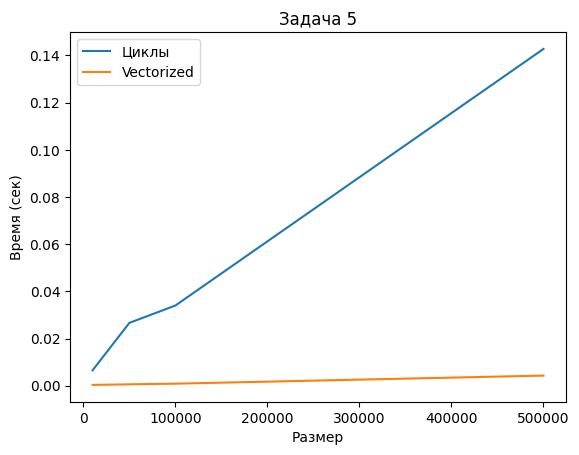

In [13]:
reload_solution_modules()

import time
import numpy as np
import matplotlib.pyplot as plt
sz = [10000, 50000, 100000, 500000]
tl = []
tv = []
for i in sz:
    x = np.random.randint(0, 5, size=i)
    t0 = time.time()
    functions.run_length_encoding(x)
    tl.append(time.time() - t0)
    t0 = time.time()
    functions_vectorized.run_length_encoding(x)
    tv.append(time.time() - t0)
plt.plot(sz, tl, label='Циклы')
plt.plot(sz, tv, label='Vectorized')
plt.title('Задача 5')
plt.xlabel('Размер')
plt.ylabel('Время (сек)')
plt.legend()
plt.show()



* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

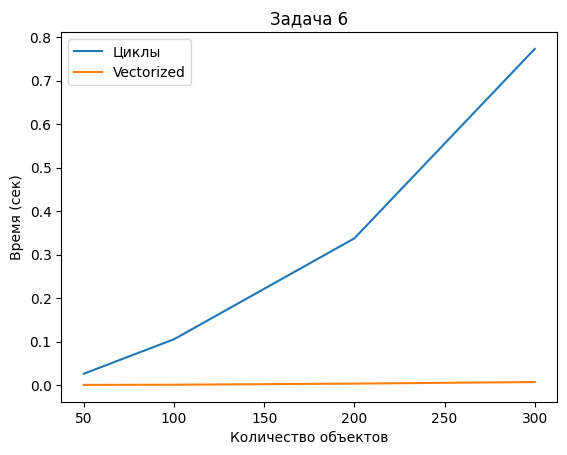

In [14]:
reload_solution_modules()
import time
import numpy as np
import matplotlib.pyplot as plt
sz = [50, 100, 200, 300]
tl = []
tv = []
for i in sz:
    X = np.random.rand(i, 10)
    Y = np.random.rand(i, 10)
    t0 = time.time()
    functions.pairwise_distance(X, Y)
    tl.append(time.time() - t0)
    t0 = time.time()
    functions_vectorized.pairwise_distance(X, Y)
    tv.append(time.time() - t0)
plt.plot(sz, tl, label='Циклы')
plt.plot(sz, tv, label='Vectorized')
plt.title('Задача 6')
plt.xlabel('Количество объектов')
plt.ylabel('Время (сек)')
plt.legend()
plt.show()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

In [15]:
Непрерывность памяти :
Обычный питоновский список — это по сути массив указателей на разбросанные в оперативной памяти объекты. На поиск каждого элемента тратится время кэша процессора.
numpy.array хранит все данные в одном сплошном блоке памяти, поэтому процессор читает их линейно со скоростью самого железа, забивая кэш без лишних прыжков.
Одна инструкция — много данных:
Когда ты пишешь np.dot() или складываешь массивы через +, NumPy не гоняет цикл поштучно. Он отправляет задачу процессору, который за один такт тактового генератора через SIMD перемножает сразу по 4, 8 или 16 чисел параллельно.
Конец накладным расходам Python:
Питоновский цикл for на каждой итерации проверяет тип данных, лезет в хэш-таблицу локальных переменных и выделяет память. В NumPy всю эту рутину берет на себя скомпилированный код на Си,которому глубоко пофиг на питоновские проверки.
Итог: Векторизация —это не просто красивый синтаксис, это принудительный перевод вычислений с медленного интерпретатора Python на аппаратный уровень процессора.